In [91]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
import seaborn as sns
import numpy as np
from scipy.stats import norm
import os

path = "D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/ajay_data/eyegaze_normal_results/sim2"
dir_list = os.listdir(path)
 
sim_dfs= []
# prints all files
for filename in dir_list:
    if filename[-3:] == "csv":
        cur_df = pd.read_csv(path+"/"+filename)
        sim_dfs += [cur_df]

df = pd.concat(sim_dfs)
df = df.groupby(["gaze_scale","trial"],  as_index=False).mean()

df.correction_rate *= 100
df["gaze_num"] = df.gaze_scale
df.gaze_scale *= 1.66667
df.click_load *= 5/7

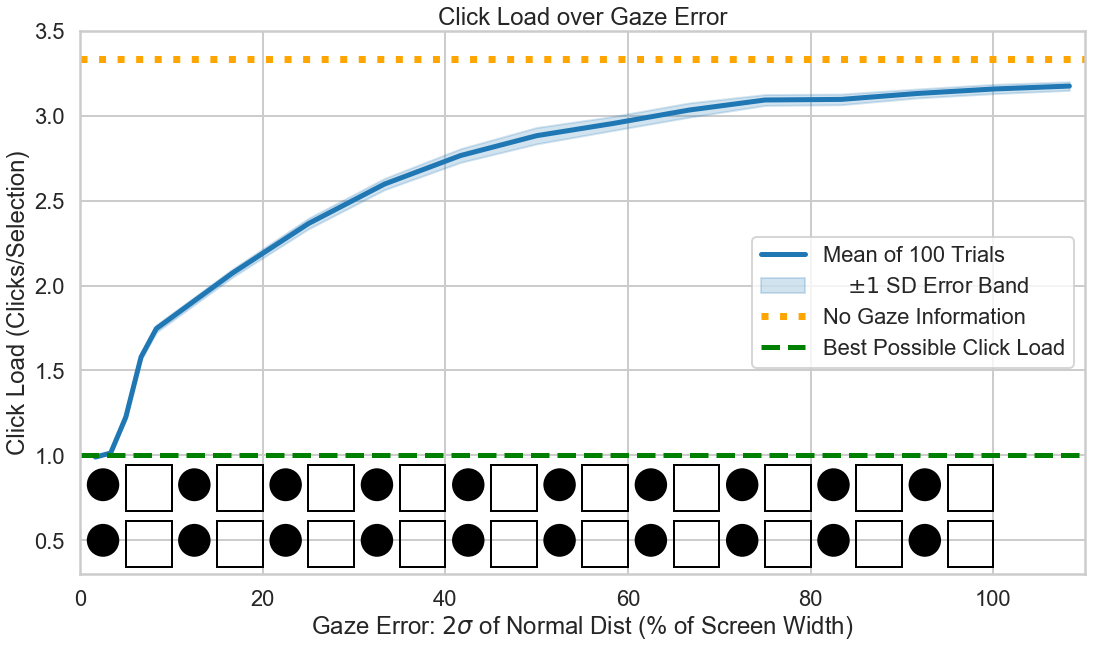

In [92]:
sns.set_context("poster")
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, figsize=(18,10))
gaze_df = df[df["gaze_scale"] != 0]
sns.lineplot(x="gaze_scale", y="click_load", data=gaze_df, linewidth=5, ax=ax, ci="sd", label="Mean of 100 Trials")

ax.collections[0].set_label('    $\pm 1$ SD Error Band')

ax.axhline(np.mean(df[df.gaze_scale == 0].click_load), color="orange", linestyle=":", linewidth=7, label="No Gaze Information")
ax.axhline(1, color="green", linestyle="--", linewidth=5, label="Best Possible Click Load")

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,3,1,2]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

ax.set_ylim(0.3,3.5)
ax.set_xlim(0,110)
plt.xlabel("Gaze Error: $2 \sigma$ of Normal Dist (% of Screen Width)")
plt.ylabel("Click Load (Clicks/Selection)")
plt.title("Click Load over Gaze Error")

for i in range(10):
    for j in range(2):
        scale_factor = 6/110
        
        clock_r = 1.667*2
        
        circle1 = Ellipse((2.5+i*10.0, 0.5+(6*j)*scale_factor), clock_r, clock_r*scale_factor, color='k', clip_on=False)
        ax.add_patch(circle1)

        rect1 = Rectangle((5+10.0*i,0.525-clock_r*scale_factor+6*j*scale_factor), clock_r*3/2, clock_r*3/2*scale_factor, color="k", fill=False)
        ax.add_patch(rect1)


plt.savefig("D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/ajay_data/figures/click_load_gaze_error.png", dpi=300)



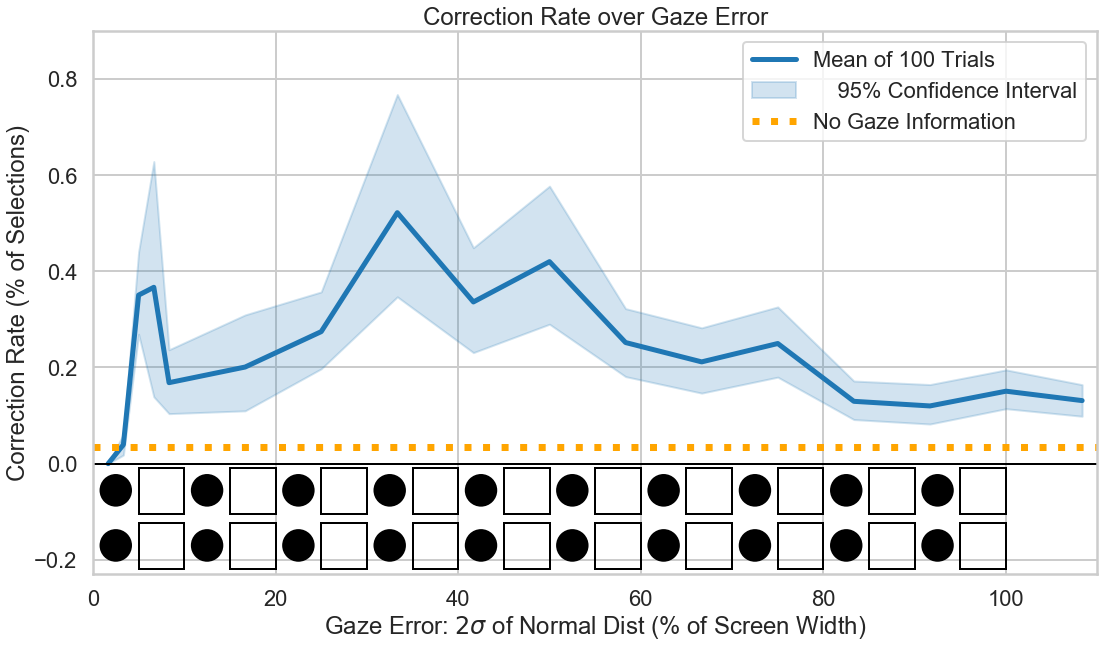

In [93]:
sns.set_context("poster")
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, figsize=(18,10))

sns.lineplot(x="gaze_scale", y="correction_rate", data=gaze_df, ax=ax, linewidth=5, label="Mean of 100 Trials")
ax.collections[0].set_label('    95% Confidence Interval')

ax.axhline(np.mean(df[df.gaze_scale == 0].correction_rate), color="orange", linestyle=":", linewidth=7, label="No Gaze Information")

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,2,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

ax.set_ylim(-0.23,0.9)
ax.set_xlim(0,110)
plt.xlabel("Gaze Error: $2 \sigma$ of Normal Dist (% of Screen Width)")
plt.ylabel("Correction Rate (% of Selections)")
plt.title("Correction Rate over Gaze Error")

ax.axhline(0, color='k', linewidth=2)
    
for i in range(10):
    for j in range(2):
        scale_factor = 2.1/110
        
        clock_r = 1.667*2
        
        circle1 = Ellipse((2.5+i*10.0, -0.17+(6*j)*scale_factor), clock_r, clock_r*scale_factor, color='k', clip_on=False)
        ax.add_patch(circle1)

        rect1 = Rectangle((5+10.0*i, -.155-clock_r*scale_factor+6*j*scale_factor), clock_r*3/2, clock_r*3/2*scale_factor, color="k", fill=False)
        ax.add_patch(rect1)
plt.savefig("D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/ajay_data/figures/correction_gaze_error.png", dpi=300)


In [32]:
screen_width = 1121
screen_height = 809
num_col = 10
num_row = 7

y_spacing = screen_height / num_row
x_spacing = screen_width / num_col

clock_radius = min(y_spacing / 3.5, x_spacing / 6.0);

print(x_spacing/clock_radius, y_spacing/clock_radius, )

print(clock_radius/screen_width*100)

6.0 6.185803491780298
1.6666666666666667


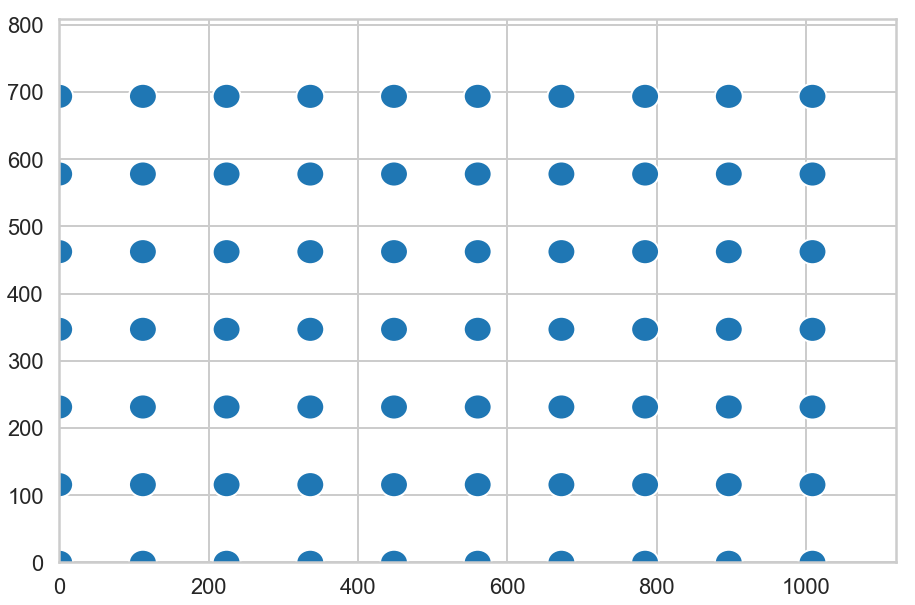

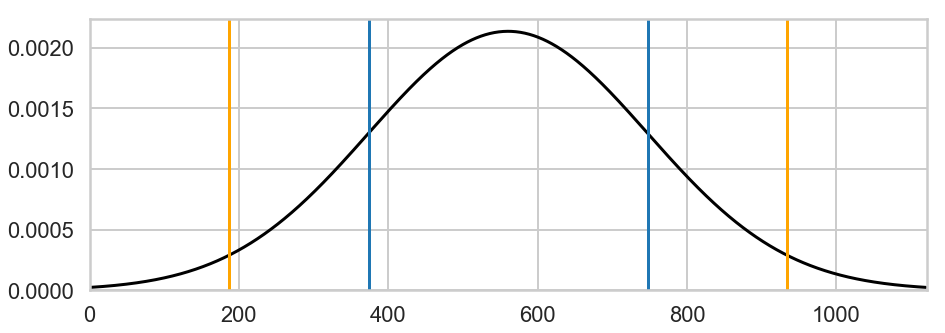

In [33]:
fig, ax = plt.subplots(1, figsize=(15,10))

for i in range(10):
    for j in range(7):
        circle = plt.Circle((x_spacing*i,y_spacing*j), clock_radius)
        ax.add_patch(circle)
    
ax.set_xlim(0, screen_width)
ax.set_ylim(0, screen_height)

# np.random.normal(target_x, self.gaze_scale*self.clock_radius/2)
plt.show()
fig, ax = plt.subplots(1, figsize=(15,5))

x_axis = np.arange(0, screen_width, 1)
# Mean = 0, SD = 2.

gaze_scale = 20


mean = screen_width/2
sigma = gaze_scale*clock_radius/2
ax.plot(x_axis, norm.pdf(x_axis, mean,sigma),  color="k")
ax.axvline(mean+sigma)
ax.axvline(mean-sigma)
ax.axvline(mean+2*sigma, color="orange")
ax.axvline(mean-2*sigma, color="orange")


ax.set_xlim(0, screen_width)
ax.set_ylim(ymin=0)
plt.show()


In [94]:
dists_from_center = []
for row in range(-5, 5):
    for col in range(-3, 4):
        dists_from_center += [(row**2+col**2)**0.5]
        
dists_from_center = np.array(dists_from_center)*x_spacing
clocks_in_sigma = {}
clocks_in_2sigma = {}
clocks_in_3sigma = {}
for num in df.gaze_num.unique():
    sigma = num*clock_radius/2
    clocks_in_sigma[num] = len(np.where(dists_from_center <= sigma)[0])
    clocks_in_2sigma[num] = len(np.where(dists_from_center <= 2*sigma)[0])
    clocks_in_3sigma[num] = len(np.where(dists_from_center <= 3*sigma)[0])
    
df["num_clocks_in_2sigma"] = np.vectorize(clocks_in_sigma.get)(df.gaze_num.values)
df["num_clocks_in_4sigma"] = np.vectorize(clocks_in_2sigma.get)(df.gaze_num.values)
df["num_clocks_in_6sigma"] = np.vectorize(clocks_in_3sigma.get)(df.gaze_num.values)

print(df["num_clocks_in_2sigma"].unique())
print(df["num_clocks_in_4sigma"].unique())
print(df["num_clocks_in_6sigma"].unique())

[ 1  5  9 13 21 25 37 45 51 59 64 68]
[ 1  9 21 37 51 64 70]
[ 1  5 21 45 64 70]


In [96]:
path = "D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/num_clocks/normal_results/"

sim_dfs= []
dir_list = os.listdir(path)
trial_offset=0
for sub_dir in dir_list:
    if os.path.isdir(path + sub_dir):
        sub_dir_list = os.listdir(path+sub_dir)
        # prints all files
        for filename in sub_dir_list:
            if filename[-3:] == "csv":
                # print(filename)
                cur_df = pd.read_csv(path+"/"+sub_dir+"/"+filename)
                cur_df.trial += trial_offset
                sim_dfs += [cur_df]
        trial_offset += 1000
        

nc_df = pd.concat(sim_dfs)
nc_df = nc_df.groupby(["num_clocks","trial"],  as_index=False).mean()
nc_df.correction_rate *= 100
nc_df.click_load *= 5/7
# nc_df = nc_df[nc_df.num_clocks <= 65]
nc_df

,num_clocks,trial,session,phrase,click_load,entry_rate,correction_rate,num_chars
0,4,0,3.024793,12.611570,1.174144,33.297666,0.000000,6.975207
1,4,1,3.008197,12.704918,1.165691,33.484393,0.000000,6.967213
2,4,2,3.008197,12.704918,1.165691,33.484393,0.000000,6.967213
3,4,3,3.008197,12.704918,1.165691,33.484393,0.000000,6.967213
4,4,4,3.008197,12.704918,1.165691,33.484393,0.000000,6.967213
...,...,...,...,...,...,...,...,...
1220,208,1010,2.941176,3.911765,4.142857,8.974337,0.000000,6.852941
1221,208,1011,3.000000,4.000000,4.077551,9.278340,0.000000,6.828571
1222,208,1012,3.058824,3.911765,4.146008,8.994007,0.000000,6.823529
1223,208,1013,3.000000,4.000000,4.098980,9.191288,0.000000,6.771429


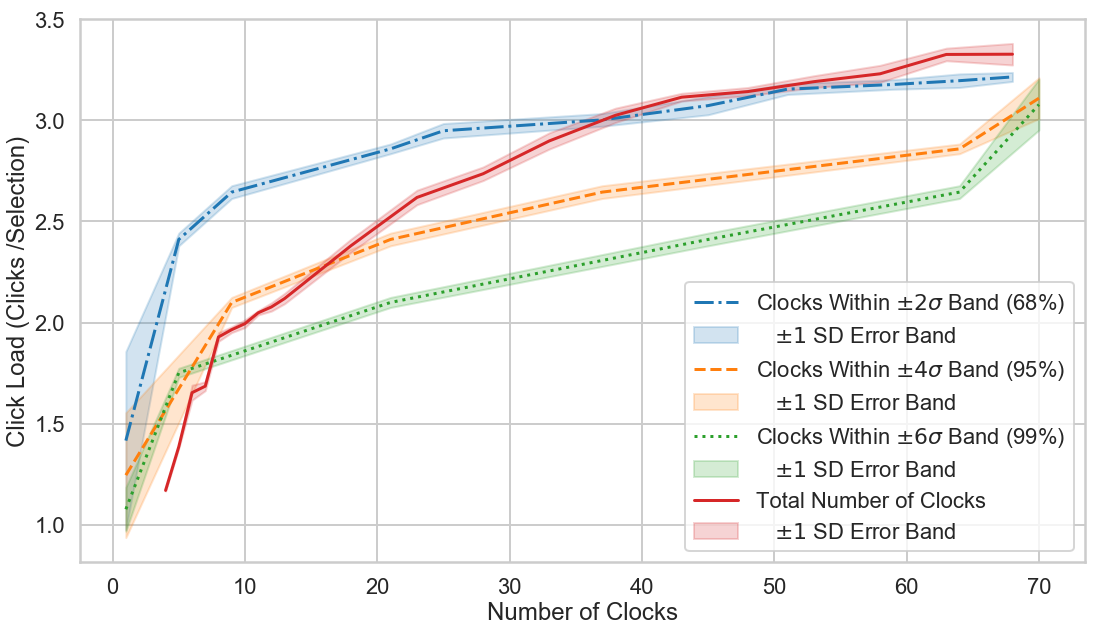

In [87]:
sns.set_context("poster")
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, figsize=(18,10))

gaze_df = df[df["gaze_scale"] != 0]

sns.lineplot(x="num_clocks_in_2sigma", y="click_load", data=gaze_df, ax=ax, label="Clocks Within $\pm 2\sigma$ Band (68%)", linestyle="-.", ci="sd")
sns.lineplot(x="num_clocks_in_4sigma", y="click_load", data=gaze_df, ax=ax, label="Clocks Within $\pm 4\sigma$ Band (95%)", linestyle="--", ci="sd")
sns.lineplot(x="num_clocks_in_6sigma", y="click_load", data=gaze_df, ax=ax, label="Clocks Within $\pm 6\sigma$ Band (99%)", linestyle=":", ci="sd")

sns.lineplot(x="num_clocks", y="click_load", data=nc_df[nc_df["num_clocks"] <= 70], ax=ax, ci="sd", label="Total Number of Clocks")

ax.collections[0].set_label('   $\pm 1$ SD Error Band')
ax.collections[1].set_label('   $\pm 1$ SD Error Band')
ax.collections[2].set_label('   $\pm 1$ SD Error Band')
ax.collections[3].set_label('   $\pm 1$ SD Error Band')
handles, labels = plt.gca().get_legend_handles_labels()
order = [0,4,1,5,2,6,3,7]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])


plt.xlabel("Number of Clocks")
plt.ylabel("Click Load (Clicks /Selection)")
plt.savefig("D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/ajay_data/figures/click_load_num_clocks.png", dpi=300)


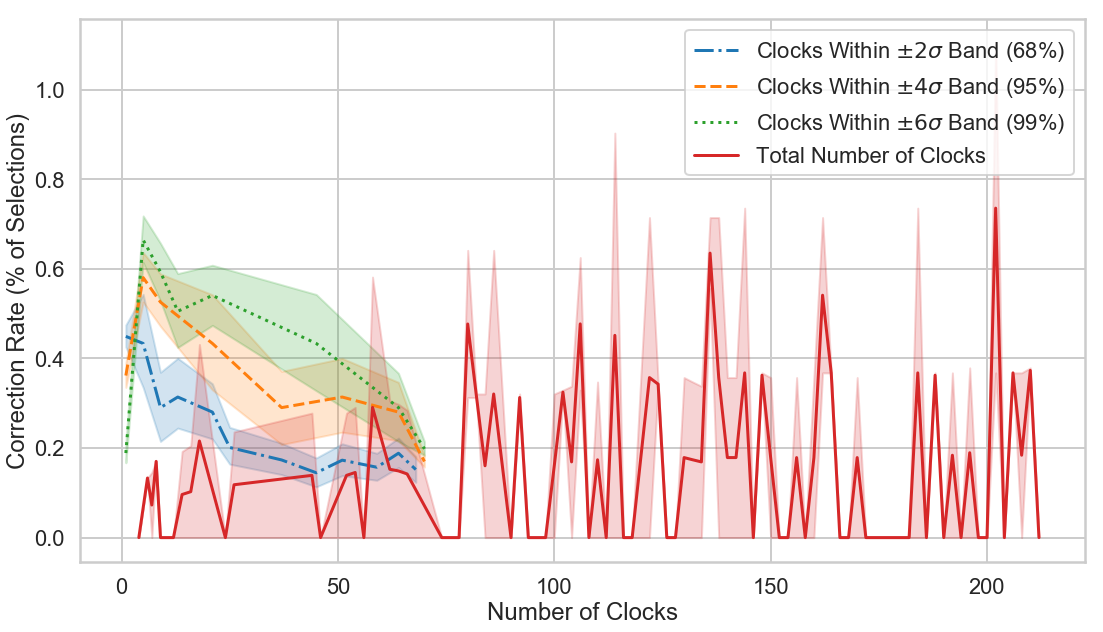

In [37]:
sns.set_context("poster")
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, figsize=(18,10))

gaze_df = df[df["gaze_scale"] != 0]

sns.lineplot(x="num_clocks_in_2sigma", y="correction_rate", data=gaze_df, ax=ax, label="Clocks Within $\pm 2\sigma$ Band (68%)", linestyle="-.")
sns.lineplot(x="num_clocks_in_4sigma", y="correction_rate", data=gaze_df, ax=ax, label="Clocks Within $\pm 4\sigma$ Band (95%)", linestyle="--")
sns.lineplot(x="num_clocks_in_6sigma", y="correction_rate", data=gaze_df, ax=ax, label="Clocks Within $\pm 6\sigma$ Band (99%)", linestyle=":")

sns.lineplot(x="num_clocks", y="correction_rate", data=nc_df, ax=ax, label="Total Number of Clocks")

# ax.collections[0].set_label('   95% Confidence Interval')
# ax.collections[1].set_label('   95% Confidence Interval')
# ax.collections[2].set_label('   95% Confidence Interval')
# ax.collections[3].set_label('   95% Confidence Interval')
# handles, labels = plt.gca().get_legend_handles_labels()
# order = [0,4,1,5,2,6,3,7]
# plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.xlabel("Number of Clocks")
plt.ylabel("Correction Rate (% of Selections)")

plt.savefig("D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/ajay_data/figures/correction_num_clocks.png", dpi=300)



ValueError: operands could not be broadcast together with shapes (4,) (0,) 

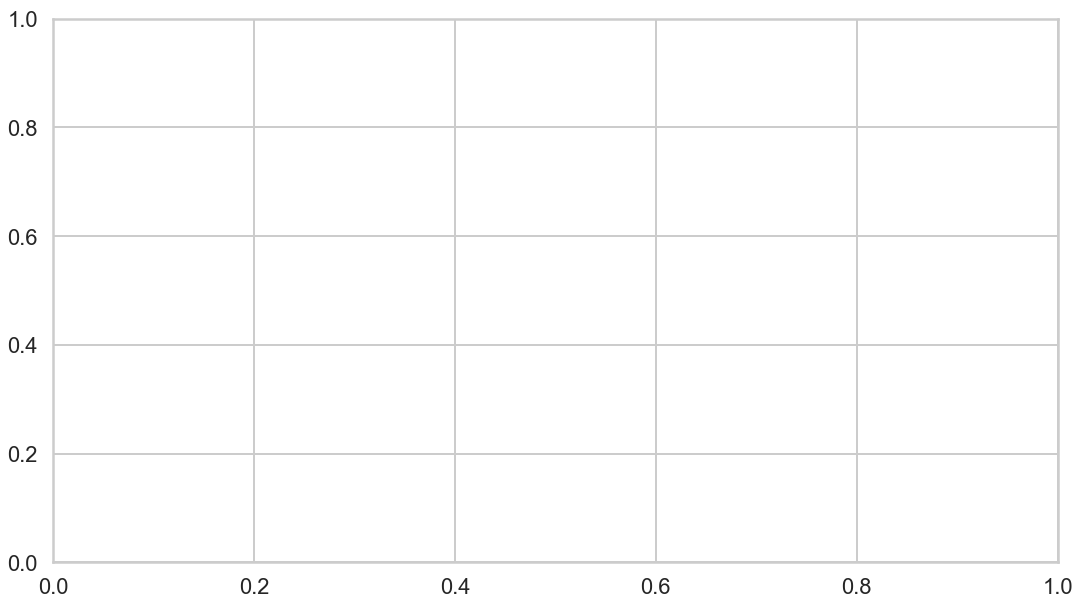

In [43]:
sns.set_context("poster")
fig, ax = plt.subplots(1, figsize=(18,10))

plot_df = nc_df["num_clocks"].groupby("num_clocks").mean()

num_clock_inds = plot_df.index.to_numpy()

new_df = pd.DataFrame(columns=["Click Load Reduction (%)", "% of Clocks Excluded", "num_clocks"])

for scale_facor in np.arange(0.3, .85, 0.1):
    valid_vals = np.unique(np.floor(num_clock_inds*scale_facor))
    valid_vals = np.intersect1d(valid_vals, num_clock_inds)
    
    valid_multiples = np.floor(valid_vals/scale_facor)
    
    vals = plot_df[plot_df.index.isin(valid_vals)].click_load.to_numpy()
    mults = plot_df[plot_df.index.isin(valid_multiples)].click_load.to_numpy()

    new_df = pd.concat([new_df, pd.DataFrame({"Click Load Reduction (%)": (1-vals/mults)*100, "% of Clocks Excluded": [int(round(100*(1-scale_facor))) for i in range(len(vals))], "num_clocks": valid_multiples})])

plt.xlabel("Number of Clocks")
sns.lineplot(x="num_clocks", y="Click Load Reduction (%)", hue="% of Clocks Excluded", sizes=(5,5), data=new_df, ax=ax)

plt.savefig("D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/ajay_data/figures/clocks_excluded.png", dpi=300)

# plt.legend()

[(11, 75), (11, 80), (11, 90), (11, 95), (13, 95), (15, 90), (17, 85), (17, 95), (17, 999), (1, 75), (1, 90), (1, 999), (21, 80), (21, 95), (25, 95), (27, 85), (27, 999), (31, 75), (31, 90), (31, 95), (31, 999), (33, 85), (35, 999), (37, 80), (37, 85), (37, 999), (39, 75), (39, 85), (3, 85), (41, 85), (41, 90), (43, 75), (43, 80), (43, 85), (43, 90), (45, 80), (45, 999), (51, 80), (51, 95), (53, 75), (53, 999), (55, 75), (55, 80), (57, 90), (5, 75), (63, 85), (67, 75), (67, 85), (69, 85), (9, 75), (9, 95)]


In [158]:
path = "D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/num_clocks/win_diff_results/"

sim_dfs= []
dir_list = os.listdir(path)
trial_offset=0
for sub_dir in dir_list:
    if os.path.isdir(path + sub_dir):
        sub_dir_list = os.listdir(path+sub_dir)
        # prints all files
        for filename in sub_dir_list:
            
            if filename[-3:] == "csv":
                # print(filename)
                cur_df = pd.read_csv(path+"/"+sub_dir+"/"+filename)
                
                cur_df.trial += trial_offset
                if "win_diff" not in cur_df.columns:
                    cur_df["win_diff"] = 99
                sim_dfs += [cur_df]
        trial_offset += 1000
        

wd_df = pd.concat(sim_dfs)

wd_df = wd_df.groupby(["num_clocks","win_diff","trial"],  as_index=False).mean()
wd_df.correction_rate *= 100
wd_df = wd_df[wd_df.num_clocks <= 65]


# wd_df.win_diff = wd_df.win_diff.replace(999, 99.9)
wd_df.win_diff = 1/wd_df.win_diff

np.unique(wd_df.win_diff.values)


array([0.001001  , 0.01010101, 0.01052632, 0.01111111, 0.01176471,
       0.0125    , 0.01333333, 0.05      , 0.07692308, 0.1       ,
       0.16666667, 0.2       , 0.33333333, 0.5       ])

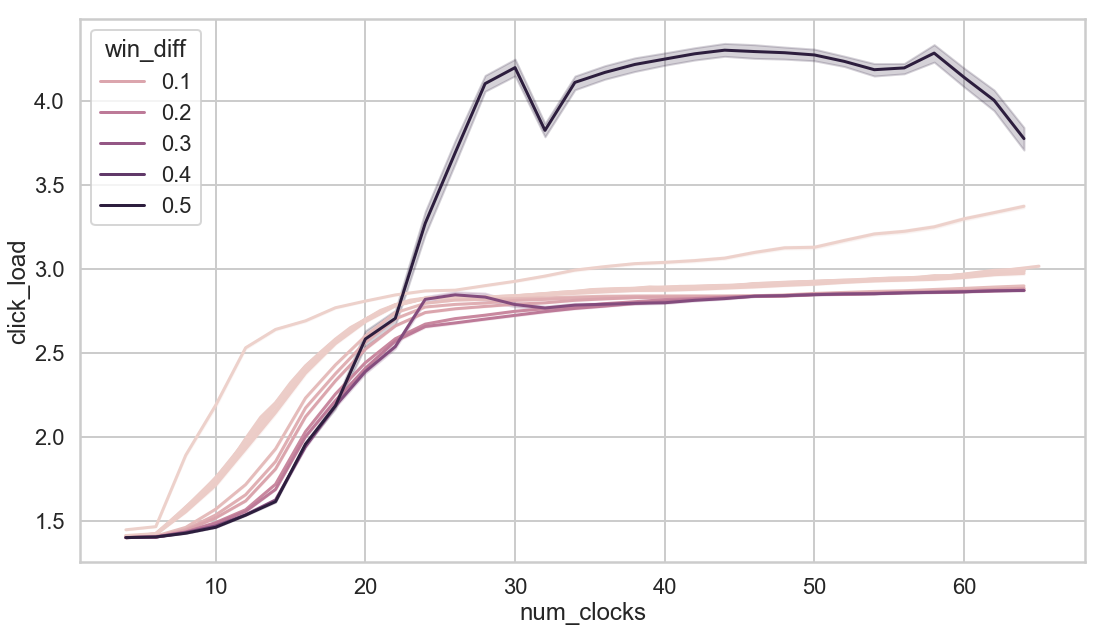

In [159]:
sns.set_context("poster")
fig, ax = plt.subplots(1, figsize=(18,10))
sns.lineplot(x="num_clocks", y="click_load", hue="win_diff", data=wd_df, ax=ax)


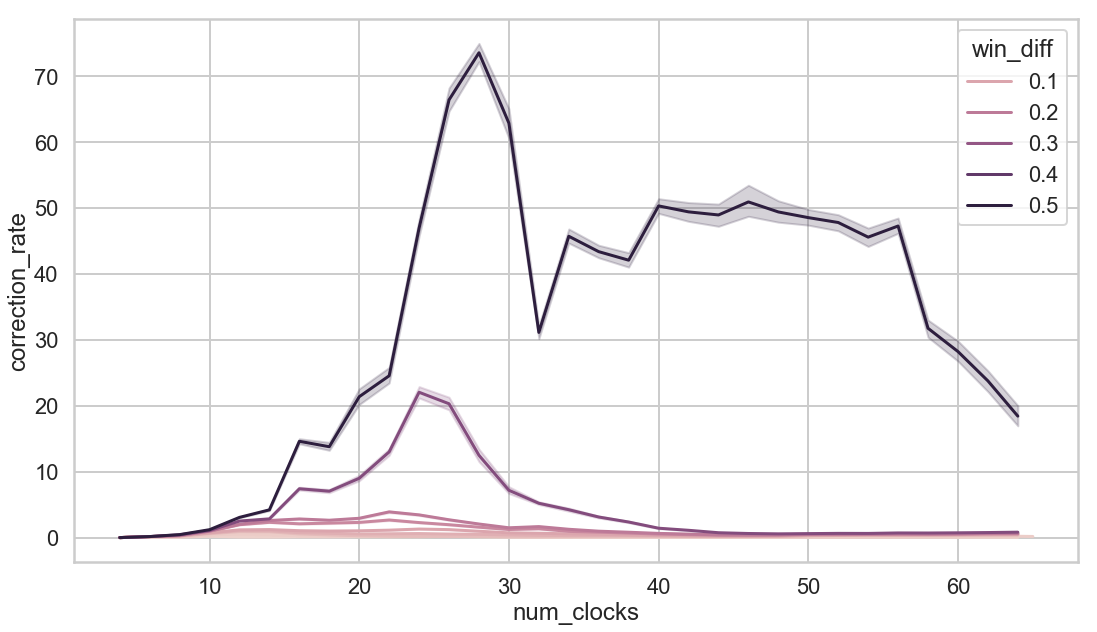

In [160]:
sns.set_context("poster")
fig, ax = plt.subplots(1, figsize=(18,10))
sns.lineplot(x="num_clocks", y="correction_rate", hue="win_diff", data=wd_df, ax=ax)


(array([  4.,  13.,  56., 114., 218., 235., 203.,  95.,  47.,  15.]),
 array([-0.33043258, -0.27017079, -0.209909  , -0.14964721, -0.08938542,
        -0.02912363,  0.03113816,  0.09139995,  0.15166174,  0.21192353,
         0.27218532]),
 <a list of 10 Patch objects>)

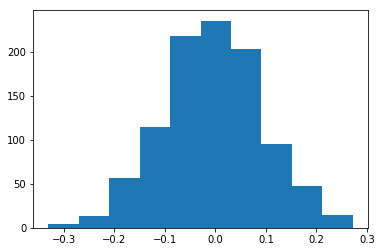

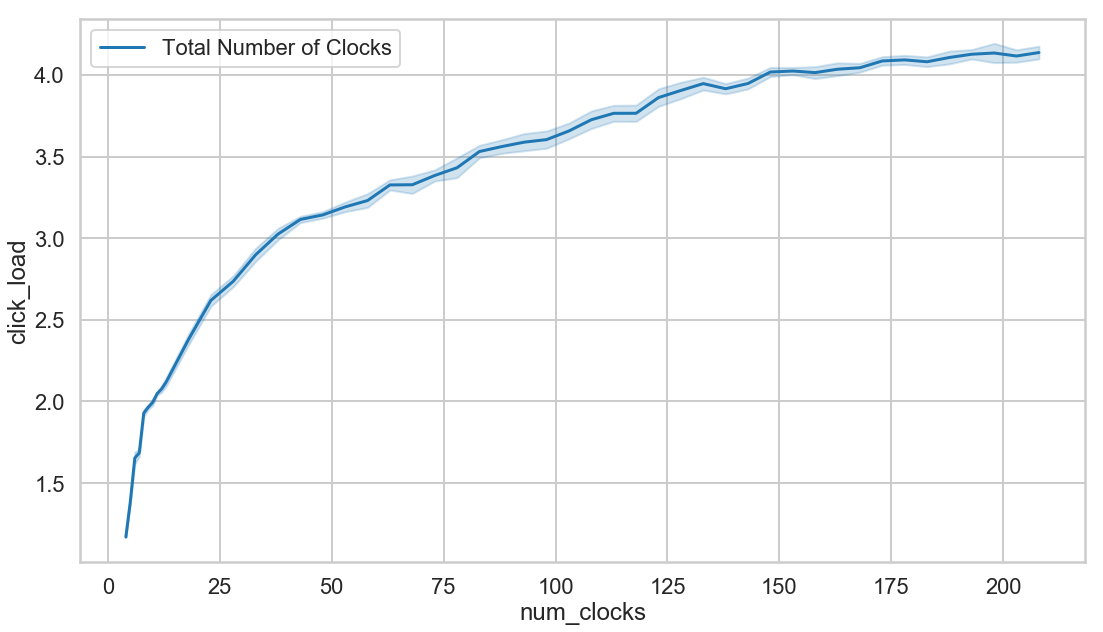

In [89]:
sns.set_style("whitegrid")
sns.set_context("poster")
fig, ax = plt.subplots(1, figsize=(18,10))
sns.lineplot(x="num_clocks", y="click_load", data=nc_df, ax=ax, ci="sd", label="Total Number of Clocks")
# ax.set_xscale('log')
plt.savefig("D:/Users/nickb/PycharmProjectsD/Nomon/keyboard/simulations/ajay_data/figures/click_load_num_clocks.png", dpi=300)

